# Structures and Metadata from Geometry Files

This notebook demonstrates parsing bridge, culvert, inline weir, and geometry metadata from HEC-RAS plain text geometry files, including:
- GeomMetadata: Efficient geometry element counts (HDF-first with text fallback)
- GeomBridge: Bridge deck, piers, coefficients, and HTAB parameters
- GeomCulvert: Culvert inventory across entire geometry files
- GeomInlineWeir: Inline weir profiles and gate configurations

## Overview

HEC-RAS geometry files contain inline structures (bridges, culverts, inline weirs) that control hydraulic behavior at specific cross-section locations. This notebook demonstrates the `geom` subpackage modules for extracting structure data.

### What You'll Learn
- Get a quick summary of geometry contents with `GeomMetadata`
- Extract bridge deck geometry, pier data, and hydraulic coefficients with `GeomBridge`
- List all culverts and their dimensions with `GeomCulvert`
- Read inline weir profiles and gate configurations with `GeomInlineWeir`

### LLM Forward Approach
- **Verification**: Compare extracted DataFrames against HEC-RAS GUI
- **Visual Outputs**: Plot bridge deck profiles and weir crest lines
- **Audit Trail**: Log all geometry file paths and structure counts

### Reference Documentation
- [HEC-RAS User's Manual, Chapter 6](https://www.hec.usace.army.mil/software/hec-ras/documentation.aspx)
- [HEC-RAS Hydraulic Reference Manual](https://www.hec.usace.army.mil/software/hec-ras/documentation.aspx)

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
from pathlib import Path
import sys

USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

if USE_LOCAL_SOURCE:
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

# Import RAS Commander modules
from ras_commander import (
    RasExamples, init_ras_project, RasPrj,
    GeomBridge, GeomCulvert, GeomInlineWeir, GeomLandCover,
)
from ras_commander.geom import GeomMetadata

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Verify which version loaded
import ras_commander
print(f"Loaded: {ras_commander.__file__}")
print(f"Working directory: {Path.cwd()}")

LOCAL SOURCE MODE: Loading from <workspace>/ras_commander


Loaded: <workspace>\ras_commander\__init__.py
Working directory: <workspace>\examples


## Parameters

In [2]:
# =============================================================================
# PARAMETERS - Edit these to customize the notebook
# =============================================================================

# Projects containing structures
PROJECT_BRIDGE = "Bridge Hydraulics"             # Has bridge structures
PROJECT_CULVERT = "ConSpan Culvert"              # Has culvert structures
PROJECT_WEIR = "Example 12 - Inline Structure"   # Has inline weir with gates
PROJECT_2D = "BaldEagleCrkMulti2D"               # For metadata comparison

PROJECT_SUFFIX = "206"     # Folder suffix for extracted projects
RAS_VERSION = "7.0"        # HEC-RAS version

## Setup: Extract Example Projects

In [3]:
# Extract all projects needed for this notebook
project_paths = RasExamples.extract_project(
    [PROJECT_BRIDGE, PROJECT_CULVERT, PROJECT_WEIR, PROJECT_2D],
    suffix=PROJECT_SUFFIX
)

bridge_path = project_paths[0]
culvert_path = project_paths[1]
weir_path = project_paths[2]
bald_eagle_path = project_paths[3]

# Initialize each project
bridge_ras = RasPrj()
init_ras_project(bridge_path, RAS_VERSION, ras_object=bridge_ras)
print(f"Bridge project: {bridge_ras.project_name} ({len(bridge_ras.geom_df)} geom files)")

culvert_ras = RasPrj()
init_ras_project(culvert_path, RAS_VERSION, ras_object=culvert_ras)
print(f"Culvert project: {culvert_ras.project_name} ({len(culvert_ras.geom_df)} geom files)")

weir_ras = RasPrj()
init_ras_project(weir_path, RAS_VERSION, ras_object=weir_ras)
print(f"Weir project: {weir_ras.project_name} ({len(weir_ras.geom_df)} geom files)")

bald_eagle_ras = RasPrj()
init_ras_project(bald_eagle_path, RAS_VERSION, ras_object=bald_eagle_ras)
print(f"2D project: {bald_eagle_ras.project_name} ({len(bald_eagle_ras.geom_df)} geom files)")

Bridge project: beaver (1 geom files)
Culvert project: ConSpan (2 geom files)
Weir project: NIT (1 geom files)


2D project: BaldEagleDamBrk (10 geom files)


## Section 1: GeomMetadata - Geometry Element Counts

`GeomMetadata.get_geometry_counts()` provides a quick summary of geometry file contents. It prefers HDF-based extraction (~10-50ms) and falls back to plain text parsing (~100-500ms) when HDF is unavailable.

In [4]:
# Get geometry counts for the bridge project
bridge_geom_row = bridge_ras.geom_df.iloc[0]
bridge_geom_path = Path(bridge_geom_row['full_path'])
bridge_hdf_path = Path(bridge_geom_row['hdf_path']) if pd.notna(bridge_geom_row.get('hdf_path')) else None

print(f"Geometry file: {bridge_geom_path.name}")
print(f"HDF available: {bridge_hdf_path is not None and bridge_hdf_path.exists()}")
print()

counts = GeomMetadata.get_geometry_counts(bridge_geom_path, bridge_hdf_path)

print("Geometry Element Counts:")
print(f"  Cross sections:      {counts['num_cross_sections']}")
print(f"  Bridges:             {counts['num_bridges']}")
print(f"  Culverts:            {counts['num_culverts']}")
print(f"  Inline weirs:        {counts['num_weirs']}")
print(f"  Gates:               {counts['num_gates']}")
print(f"  Inline structures:   {counts['num_inline_structures']} (bridges + culverts + weirs)")
print(f"  Lateral structures:  {counts['num_lateral_structures']}")
print(f"  SA/2D connections:   {counts['num_sa_2d_connections']}")
print(f"  Has 1D XS:           {counts['has_1d_xs']}")
print(f"  Has 2D mesh:         {counts['has_2d_mesh']}")
print(f"  Mesh areas:          {counts['mesh_area_names']}")
print(f"  Mesh cells:          {counts['mesh_cell_count']}")

Geometry file: beaver.g01
HDF available: True

Geometry Element Counts:
  Cross sections:      57
  Bridges:             0
  Culverts:            0
  Inline weirs:        0
  Gates:               0
  Inline structures:   0 (bridges + culverts + weirs)
  Lateral structures:  0
  SA/2D connections:   0
  Has 1D XS:           True
  Has 2D mesh:         False
  Mesh areas:          []
  Mesh cells:          0


### Compare Counts Across Projects

Run `get_geometry_counts()` on multiple projects to see the range of geometry types.

In [5]:
# Compare counts across all four projects
projects = {
    'Bridge Hydraulics': bridge_ras,
    'ConSpan Culvert': culvert_ras,
    'Inline Structure': weir_ras,
    'BaldEagleCrk 2D': bald_eagle_ras,
}

summary_rows = []
for name, ras_obj in projects.items():
    geom_row = ras_obj.geom_df.iloc[0]
    geom_path = Path(geom_row['full_path'])
    hdf_path = Path(geom_row['hdf_path']) if pd.notna(geom_row.get('hdf_path')) else None
    
    c = GeomMetadata.get_geometry_counts(geom_path, hdf_path)
    summary_rows.append({
        'Project': name,
        'XS': c['num_cross_sections'],
        'Bridges': c['num_bridges'],
        'Culverts': c['num_culverts'],
        'Weirs': c['num_weirs'],
        'Gates': c['num_gates'],
        'Laterals': c['num_lateral_structures'],
        '2D Areas': len(c['mesh_area_names']),
        'Mesh Cells': c['mesh_cell_count'],
    })

summary_df = pd.DataFrame(summary_rows)
print("Geometry Element Summary Across Projects:")
display.display(summary_df)

Geometry Element Summary Across Projects:


,Project,XS,Bridges,Culverts,Weirs,Gates,Laterals,2D Areas,Mesh Cells
0,Bridge Hydraulics,57,0,0,0,0,0,0,0
1,ConSpan Culvert,10,0,0,0,0,0,0,0
2,Inline Structure,36,0,0,1,1,0,0,0
3,BaldEagleCrk 2D,192,0,0,0,1,0,3,4120


## Section 2: GeomBridge - Bridge Extraction

The Bridge Hydraulics example project contains a bridge structure with deck geometry, piers, and hydraulic coefficients.

### 2.1 List All Bridges

In [6]:
# List all bridges in the geometry file
bridges_df = GeomBridge.get_bridges(bridge_geom_path)

print(f"Bridges found: {len(bridges_df)}")
print()
display.display(bridges_df)

Bridges found: 1



,River,Reach,RS,NodeName,NumDecks,NumUpstreamDeckPoints,NumDownstreamDeckPoints,DeckDistance,DeckWidth,WeirCoefficient,Skew,MaxSubmergence,NumPiers,HasAbutment,HTabHWMax,NodeLastEdited
0,Beaver Creek,Kentwood,5.4,None,6,6,6,30.0,40.0,2.6,0.0,0.95,9,False,225.0,Dec/17/2002 15:45:09


### 2.2 Bridge Deck Geometry

The deck profile defines the station-elevation points of the bridge deck (high chord) and low chord.

In [7]:
# Extract deck geometry for the first bridge
br = bridges_df.iloc[0]
river = br['River']
reach = br['Reach']
rs = br['RS']

print(f"Bridge at {river}, {reach}, RS {rs}")
print()

deck_df = GeomBridge.get_deck(bridge_geom_path, river, reach, rs)
print(f"Deck points: {len(deck_df)}")
display.display(deck_df)

Bridge at Beaver Creek, Kentwood, RS 5.4

Deck points: 12


,Location,Station,Elevation,LowChord
0,upstream,0.0,216.93,200.0
1,upstream,450.0,216.93,200.0
2,upstream,450.0,216.93,215.7
3,upstream,647.0,216.93,215.7
4,upstream,647.0,216.93,200.0
5,upstream,2000.0,216.93,200.0
6,downstream,0.0,216.93,200.0
7,downstream,450.0,216.93,200.0
8,downstream,450.0,216.93,215.7
9,downstream,647.0,216.93,215.7


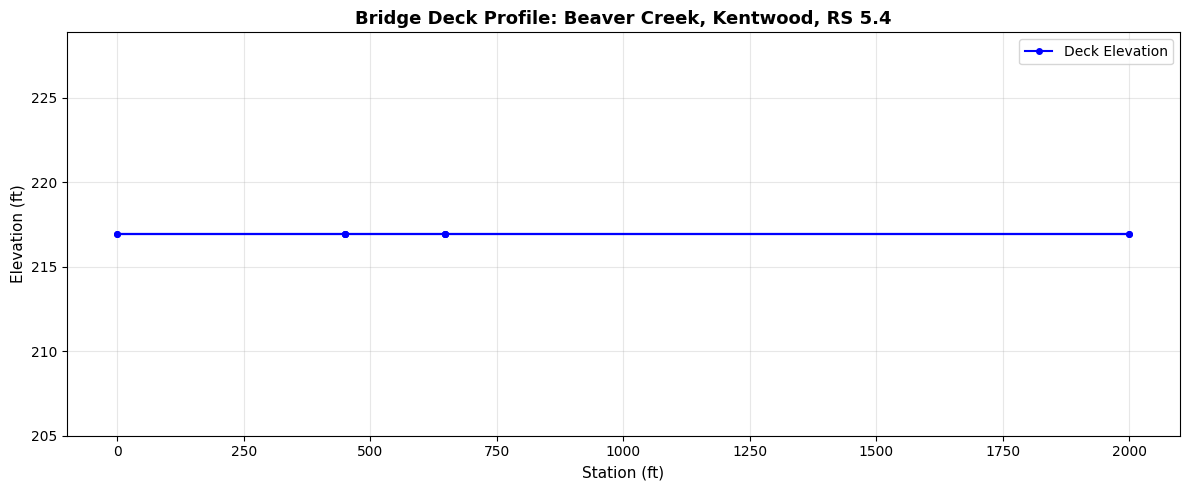

In [8]:
# Visualize bridge deck profile
if len(deck_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if 'HighChord' in deck_df.columns and 'LowChord' in deck_df.columns:
        ax.plot(deck_df['Station'], deck_df['HighChord'], 'b-o', label='High Chord (Top of Deck)', markersize=4)
        ax.plot(deck_df['Station'], deck_df['LowChord'], 'r-o', label='Low Chord (Bottom of Deck)', markersize=4)
        ax.fill_between(deck_df['Station'], deck_df['LowChord'], deck_df['HighChord'],
                        alpha=0.3, color='gray', label='Deck Cross-Section')
    elif 'Elevation' in deck_df.columns:
        ax.plot(deck_df['Station'], deck_df['Elevation'], 'b-o', label='Deck Elevation', markersize=4)
    
    ax.set_xlabel('Station (ft)', fontsize=11)
    ax.set_ylabel('Elevation (ft)', fontsize=11)
    ax.set_title(f'Bridge Deck Profile: {river}, {reach}, RS {rs}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 2.3 Pier Data

In [9]:
# Extract pier definitions
piers_df = GeomBridge.get_piers(bridge_geom_path, river, reach, rs)

print(f"Piers found: {len(piers_df)}")
if len(piers_df) > 0:
    print()
    display.display(piers_df)

Piers found: 9



,PierIndex,Skew,UpstreamStation,NumUpstreamPoints,DownstreamStation,NumDownstreamPoints,UpstreamWidths,UpstreamElevations,DownstreamWidths,DownstreamElevations
0,1,None,470.0,2,470.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
1,2,None,490.0,2,490.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
2,3,None,510.0,2,510.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
3,4,None,530.0,2,530.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
4,5,None,550.0,2,550.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
5,6,None,570.0,2,570.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
6,7,None,590.0,2,590.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
7,8,None,610.0,2,610.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"
8,9,None,630.0,2,630.0,2,"[1.25, 1.25]","[202.7, 215.7]","[1.25, 1.25]","[202.7, 215.7]"


### 2.4 Hydraulic Coefficients

In [10]:
# Extract hydraulic coefficients
coeffs_df = GeomBridge.get_coefficients(bridge_geom_path, river, reach, rs)

print(f"Coefficient rows: {len(coeffs_df)}")
if len(coeffs_df) > 0:
    print()
    display.display(coeffs_df)

Coefficient rows: 26



,ParameterType,Index,Value
0,br_coef,0,-1.0
1,br_coef,1,0.0
2,br_coef,2,0.0
3,br_coef,4,0.0
4,br_coef,6,0.34
5,br_coef,7,0.7
6,br_coef,8,0.0
7,br_coef,10,1.0
8,wspro,4,1.0
9,wspro,8,0.0


### 2.5 HTAB Parameters

In [11]:
# Extract hydraulic table parameters
htab_df = GeomBridge.get_htab(bridge_geom_path, river, reach, rs)

print("HTAB Parameters (DataFrame):")
display.display(htab_df)

# Also available as dict (includes invert elevation)
htab_dict = GeomBridge.get_htab_dict(bridge_geom_path, river, reach, rs)
print()
print("HTAB Parameters (dict):")
for key, value in htab_dict.items():
    print(f"  {key}: {value}")

HTAB Parameters (DataFrame):


,Parameter,Value
0,HWMax,225.0
1,TWMax,220.0
2,MaxFlow,50000.0
3,UseCurves,0.0
4,FreeFlowCurves,0.0



HTAB Parameters (dict):
  hw_max: 225.0
  tw_max: 220.0
  max_flow: 50000.0
  use_user_curves: 0
  free_flow_points: 0
  submerged_curves: None
  points_per_curve: None
  invert: 200.0
  has_htab_lines: True


### 2.6 Approach Sections and Abutment

In [12]:
# Extract approach sections (BR U and BR D cross sections)
approach_df = GeomBridge.get_approach_sections(bridge_geom_path, river, reach, rs)
print(f"Approach section points: {len(approach_df)}")
if len(approach_df) > 0:
    display.display(approach_df.head(10))

# Extract abutment geometry (not all bridges have abutments)
if br.get('HasAbutment', False):
    abutment_df = GeomBridge.get_abutment(bridge_geom_path, river, reach, rs)
    print(f"\nAbutment points: {len(abutment_df)}")
    if len(abutment_df) > 0:
        display.display(abutment_df)
else:
    print("\nNo abutment data for this bridge (HasAbutment=False)")

Approach section points: 0

No abutment data for this bridge (HasAbutment=False)


## Section 3: GeomCulvert - Culvert Extraction

The ConSpan Culvert example project contains culvert structures. `GeomCulvert.get_all()` scans the entire geometry file for all culverts.

In [13]:
# Get the culvert geometry file
culvert_geom_row = culvert_ras.geom_df.iloc[0]
culvert_geom_path = Path(culvert_geom_row['full_path'])

print(f"Geometry file: {culvert_geom_path.name}")
print()

# List all culverts in the entire geometry file
all_culverts = GeomCulvert.get_all(culvert_geom_path)

print(f"Total culverts found: {len(all_culverts)}")
if len(all_culverts) > 0:
    print(f"Columns: {list(all_culverts.columns)}")
    print()
    display.display(all_culverts)

Geometry file: ConSpan.g01

Total culverts found: 1
Columns: ['RecordType', 'CulvertName', 'Shape', 'ShapeName', 'Span', 'Rise', 'Length', 'ManningsN', 'EntranceLoss', 'ExitLoss', 'InletType', 'OutletType', 'UpstreamInvert', 'UpstreamStation', 'DownstreamInvert', 'DownstreamStation', 'UpstreamStations', 'DownstreamStations', 'BarrelStations', 'ChartNumber', 'CulvertCode', 'BottomN', 'BottomDepth', 'NumBarrels', 'River', 'Reach', 'RS']



,RecordType,CulvertName,Shape,ShapeName,Span,Rise,Length,ManningsN,EntranceLoss,ExitLoss,...,DownstreamStations,BarrelStations,ChartNumber,CulvertCode,BottomN,BottomDepth,NumBarrels,River,Reach,RS
0,Culvert,Culvert # 1,9,Con Span,6.0,28.0,50.0,0.013,0.5,1.0,...,[1000.0],"[(1000.0, 1000.0)]",5,0,0.03,0.5,1,Spring Creek,Culvrt Reach,20.237


In [14]:
# Summarize culvert properties
if len(all_culverts) > 0:
    print("Culvert Summary:")
    
    # Group by shape type
    if 'ShapeName' in all_culverts.columns:
        print("\nCulverts by shape type:")
        print(all_culverts.groupby('ShapeName').size().to_string())
    
    # Show dimensions
    for _, culvert in all_culverts.iterrows():
        name = culvert.get('CulvertName', 'Unknown')
        shape = culvert.get('ShapeName', 'Unknown')
        span = culvert.get('Span', 0)
        rise = culvert.get('Rise', 0)
        length = culvert.get('Length', 0)
        mannings = culvert.get('ManningsN', 0)
        print(f"\n  {name} ({shape}):")
        print(f"    Span: {span:.1f} ft, Rise: {rise:.1f} ft")
        print(f"    Length: {length:.1f} ft")
        print(f"    Manning's n: {mannings}")
        if 'UpstreamInvert' in all_culverts.columns:
            print(f"    US Invert: {culvert['UpstreamInvert']:.2f} ft, DS Invert: {culvert['DownstreamInvert']:.2f} ft")

Culvert Summary:

Culverts by shape type:
ShapeName
Con Span    1

  Culvert # 1 (Con Span):
    Span: 6.0 ft, Rise: 28.0 ft
    Length: 50.0 ft
    Manning's n: 0.013
    US Invert: 25.10 ft, DS Invert: 25.00 ft


## Section 4: GeomInlineWeir - Inline Weir and Gate Extraction

The Example 12 project contains an inline weir structure with gate groups. `GeomInlineWeir` extracts the weir profile and gate configurations.

### 4.1 List Inline Weirs

In [15]:
# Get the weir geometry file
weir_geom_row = weir_ras.geom_df.iloc[0]
weir_geom_path = Path(weir_geom_row['full_path'])

print(f"Geometry file: {weir_geom_path.name}")
print()

# List all inline weirs
weirs_df = GeomInlineWeir.get_weirs(weir_geom_path)

print(f"Inline weirs found: {len(weirs_df)}")
if len(weirs_df) > 0:
    display.display(weirs_df)

Geometry file: NIT.g01

Inline weirs found: 1


,River,Reach,RS,NodeName,PilotFlow,Distance,Width,Coefficient,Skew,MaxSubmergence,MinElevation,IsOgee,SpillwayHeight,DesignHead,HasGate,NumOpenings
0,Nittany River,Weir Reach,41.75,None,0,20.0,50.0,3.95,0.0,0.95,None,-1,24.0,3.0,True,5


### 4.2 Weir Crest Profile

The weir profile defines the station-elevation points along the weir crest.

In [16]:
if len(weirs_df) > 0:
    # Get the first weir's location
    weir = weirs_df.iloc[0]
    w_river = weir['River']
    w_reach = weir['Reach']
    w_rs = weir['RS']
    
    print(f"Weir at {w_river}, {w_reach}, RS {w_rs}")
    print()
    
    # Extract weir profile
    profile_df = GeomInlineWeir.get_profile(weir_geom_path, w_river, w_reach, w_rs)
    
    print(f"Profile points: {len(profile_df)}")
    display.display(profile_df)
else:
    print("No inline weirs found")

Weir at Nittany River, Weir Reach, RS 41.75

Profile points: 6


,Station,Elevation
0,0.0,13.5
1,57.0,13.5
2,61.0,9.5
3,190.0,9.5
4,194.0,13.5
5,1000.0,13.5


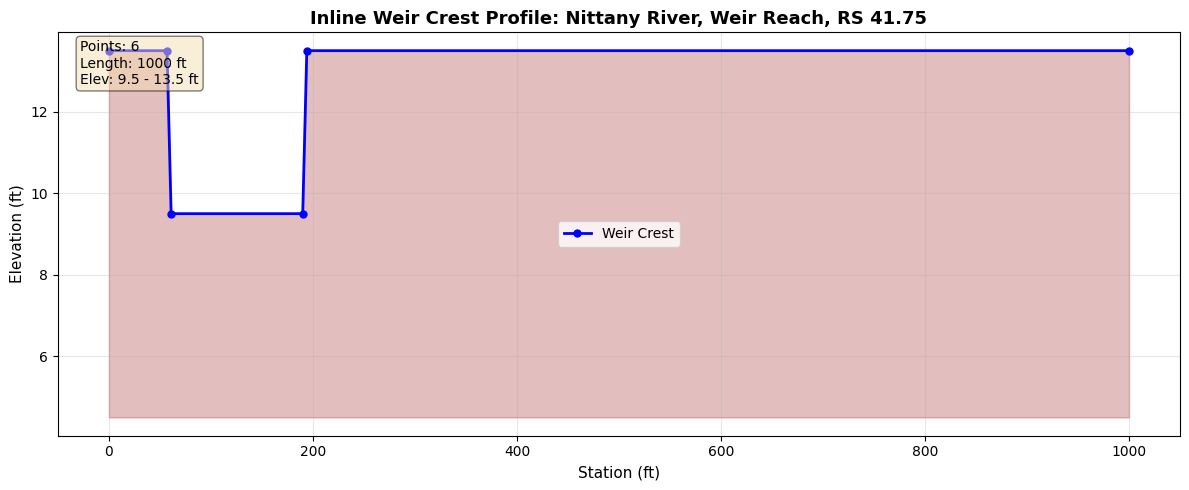

In [17]:
# Visualize weir crest profile
if len(weirs_df) > 0 and len(profile_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(profile_df['Station'], profile_df['Elevation'], 'b-o',
            linewidth=2, markersize=5, label='Weir Crest')
    ax.fill_between(profile_df['Station'], profile_df['Elevation'],
                    profile_df['Elevation'].min() - 5,
                    alpha=0.3, color='brown')
    
    ax.set_xlabel('Station (ft)', fontsize=11)
    ax.set_ylabel('Elevation (ft)', fontsize=11)
    ax.set_title(f'Inline Weir Crest Profile: {w_river}, {w_reach}, RS {w_rs}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    crest_len = profile_df['Station'].max() - profile_df['Station'].min()
    stats_text = '\n'.join([
        f'Points: {len(profile_df)}',
        f'Length: {crest_len:.0f} ft',
        f'Elev: {profile_df["Elevation"].min():.1f} - {profile_df["Elevation"].max():.1f} ft',
    ])
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)
    
    plt.tight_layout()
    plt.show()

### 4.3 Gate Configurations

Inline weirs may include gate groups that control flow. Each gate group has opening stations defining where along the weir the gate is located.

In [18]:
if len(weirs_df) > 0:
    # Extract gate configurations
    gates_df = GeomInlineWeir.get_gates(weir_geom_path, w_river, w_reach, w_rs)
    
    print(f"Gate groups found: {len(gates_df)}")
    if len(gates_df) > 0:
        print()
        # Show gate parameters (excluding OpeningStations list for cleaner display)
        display_cols = [c for c in gates_df.columns if c != 'OpeningStations']
        display.display(gates_df[display_cols])
        
        # Show opening stations for each gate group
        print("\nGate opening stations:")
        for _, gate in gates_df.iterrows():
            name = gate.get('GateName', gate.get('Name', f'Gate {_}'))
            stations = gate.get('OpeningStations', [])
            n_openings = gate.get('NumOpenings', len(stations) if isinstance(stations, list) else 0)
            print(f"  {name}: {n_openings} openings")
            if isinstance(stations, list) and len(stations) > 0:
                for i, sta in enumerate(stations):
                    print(f"    Opening {i+1}: station {sta}")
    else:
        print("No gates defined for this weir")
else:
    print("No inline weirs found")

Gate groups found: 3



,GateName,Width,Height,InvertElevation,GateCoefficient,ExpansionTop,ExpansionOrifice,ExpansionHydraulic,GateType,WeirCoefficient,IsOgee,SpillwayHeight,DesignHead,NumOpenings
0,Left Group,30.0,10.0,0.0,0.8,0.16,0.72,0.62,1.0,3.91,-1,14.0,10.0,5
1,Center Group,30.0,10.0,0.0,0.8,0.16,0.72,0.62,1.0,3.76,-1,4.0,10.0,5
2,Right Group,30.0,10.0,0.0,0.8,0.16,0.72,0.62,1.0,3.76,-1,4.0,10.0,5



Gate opening stations:
  Left Group: 5 openings
    Opening 1: station 220.0
    Opening 2: station 255.0
    Opening 3: station 290.0
    Opening 4: station 325.0
    Opening 5: station 360.0
  Center Group: 5 openings
    Opening 1: station 395.0
    Opening 2: station 430.0
    Opening 3: station 465.0
    Opening 4: station 500.0
    Opening 5: station 535.0
  Right Group: 5 openings
    Opening 1: station 570.0
    Opening 2: station 605.0
    Opening 3: station 640.0
    Opening 4: station 675.0
    Opening 5: station 710.0


## Summary

### Methods Demonstrated

**GeomMetadata** (geometry element counting):
- `get_geometry_counts(geom_path, hdf_path)` - Quick inventory of all geometry elements

**GeomBridge** (bridge structures):
- `get_bridges()` - List all bridges with river/reach/RS
- `get_deck()` - Deck high chord and low chord geometry
- `get_piers()` - Pier widths and elevations
- `get_coefficients()` - Hydraulic loss coefficients
- `get_htab()` / `get_htab_dict()` - Hydraulic table parameters
- `get_approach_sections()` - BR U/BR D cross sections
- `get_abutment()` - Abutment geometry

**GeomCulvert** (culvert structures):
- `get_all()` - List all culverts across entire geometry file
- `get_culverts()` - List culverts at a specific bridge/culvert structure

**GeomInlineWeir** (inline weirs and gates):
- `get_weirs()` - List all inline weirs
- `get_profile()` - Station-elevation weir crest profile
- `get_gates()` - Gate group configurations with opening stations

### Key Patterns
- All classes use **static methods** (no instantiation needed)
- Methods accept geometry file path as first argument
- Bridge/culvert/weir methods require river, reach, RS to identify the structure
- All methods return **DataFrames** for consistent data handling